In [1]:
from typing import TypedDict, Annotated, Literal
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage

from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI
from eurospark.config import settings

from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

import pandas as pd
import plotly.express as px

In [2]:
class GraphState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next_node: str | None
    sql_result: str | None       # raw query result
    chart_base64: str | None     # plotly chart as base64 PNG
    schema_context: str | None   # table schemas injected into prompt
    queue_responder: bool # lets the supervisor skip himself after the next task is complete and instead let the responder handle the users question
    #query_type: str | None       # 'sql', 'viz', or 'direct'

## Supervisor node

In [3]:
class SupervisorDecision(BaseModel):
    reasoning: str = Field(
        description = "In maximum 3 sentences, think about what task needs to be solved next.")
    next: Literal["responder", "sql_agent", "chart_agent", "user_clarification"]   # The llm will choice one of these options, this will set 'next_node' in the state
    queue_responder: bool = Field(
      default=False,
      description="Set to True when the task you just selected will give the responder everything it needs to answer the user. Set to False when more tasks are needed first (e.g. a chart still needs to be made after SQL)."
  )

In [4]:
llm = ChatOpenAI(model="gpt-4o-mini", openai_api_key=settings.openai_api_key, temperature=0)
llm_supervisor = llm.with_structured_output(SupervisorDecision)

In [5]:
SYSTEM_PROMPT_SUPERVISOR = """ You are a supervisor. You oversee Eurospark, an application that will answer a users questions about the European electricity market.
    These questions can be answered with the help of a PostgreSQL database of European electricity market data.

    Given the current messages you have to decide what the next course of action is. What is the NEXT task that needs completing?
    Look at the user's question and also at the message history to review what steps have already taken place in the application before this moment.
    Do not only reason about what the next task is, but try to reason also 1 extra step ahead. In other words try to think about the next 2 tasks.
    
    Your options for the next task are:
    - sql_agent: This is an agent that will use the users questions and the available information to query the database by writing a SELECT query.
    If succesfull this agents results will be placed in the messages history.
    Use this when we need to query the database

    - chart_agent: This agent will look at the query results already in the message history and the user's question to decide the best chart type and render a visualization.
    Use this when the user asks for a chart, plot, or graph.
    IMPORTANT: chart_agent REQUIRES SQL data to already be in the message history.
    - If data is NOT yet in the history: route to sql_agent FIRST. Set queue_responder=False
      so the supervisor gets control back to then route to chart_agent.
    - If the data needed to make the plot IS already in the history: route directly to chart_agent and set queue_responder=True,
      since the responder will follow immediately after.

    - responder: This agent will use the users question and the available information in the message history to best answer the users question
    and synthesise the information.
    Route here if the users asks a question where there no additional information or action is required
    or if all the information needed is already in the message history.
    Use this when when we are ready to answer the users question.

    - user_clarification: This will prompt the user for some additional clearification on their question. Use this if it is not clear what the user is askinkg for.
    Or if some clearification could significantly improve this appplications ability to answer their question better. 
    This option can also be picked when there somesort of problem, perhaps the query returned an error because the user is asked a question that is out of the scope of the database, etc.
    Use this only if needed.

    When you pick one of these options, the app will handle this task and then return the controll to you, the supervisor once more to pick the next task.
    So when multiple tasks are needed, it is worth considering what task needs to happend FIRST.

    Additionally you also have the option to turn 'queue_responder' to True. Doing this will queue the responder to act immediately AFTER the option/task you selected here.
    Preferably this is set to true (queue_responder=True) unless multiple tasks need to be completed before calling the resonder.
    For example set it as TRUE when:
    The users has asked a question that requires an SQL query to be run, but after this Eurospark will have all the data needed to formulate a users response,
    in this case you select the sql_agent as the NEXT task and then additianlly you could queue the responder already by turning 'queue_responder' = True.
    This would thus results in the sql agent handeling the query immediately followed by the responder synthesising the best answer using this data for the user. SQL query -> responder
    For example set it as FALSE when:
    Multiple other asks are needed before the responder has the data to respond to the users questions. For example SQL query -> supervisor -> chart -> responder

    IMPORTANT RULES:
    - Pay attention to the entire message history to make your decision, NOT only to the user input
    - Pay special attention also to messages telling you wether a task has been completed or failed
    - ALWAYS set queue_responder=True unless you are certain another task is needed
      before the responder can answer.
    - You MUST actively decide the que_responder for every routing decision.
      Add your reasoning for why queue_responder is set to false or true in the reasoning field
    """

In [6]:
def supervisor_node(state: GraphState) -> GraphState:
    messages = state["messages"]
    print(messages[-1].content)
    print(f'\n')
    system_prompt = SystemMessage(content=SYSTEM_PROMPT_SUPERVISOR)
    decision = llm_supervisor.invoke([system_prompt] + messages)
    print(decision.reasoning)
    return {"next_node": decision.next, "queue_responder": decision.queue_responder}

In [196]:
fake_state = {"messages": [HumanMessage(content="what kind of questions can I ask you")]}
result = supervisor_node(fake_state)
print(result)

content='what kind of questions can I ask you' additional_kwargs={} response_metadata={}
The user is asking for clarification on the types of questions they can ask, which does not require any additional data or action. Therefore, I will route to the responder to provide a clear answer.
{'next_node': 'responder', 'queue_responder': False}


## SQL node

In [7]:
from supabase import create_client
import base64, json, io
from eurospark.config import settings

sb = create_client(settings.supabase_url, settings.supabase_key)

schema = sb.rpc("get_eurospark_schema", {}).execute()
schema = json.dumps(schema.data, indent=2)
print(schema)

def execute_sql(query: str) -> str:
    """Executes a read-only SQL query against the eurospark schema. Returns JSON results."""
    # ✅ remove trailing semicolons (and whitespace)
    query = query.strip().rstrip(";")

    result = sb.rpc("execute_readonly_sql", {"query": query}).execute()
    return json.dumps(result.data)

[
  {
    "table": "electricity_prices",
    "columns": [
      "id",
      "country_code",
      "country_name",
      "year",
      "quarter",
      "consumer_type",
      "price_eur_kwh",
      "currency"
    ]
  },
  {
    "table": "renewable_capacity",
    "columns": [
      "id",
      "country_code",
      "country_name",
      "year",
      "source",
      "capacity_gw",
      "share_pct"
    ]
  },
  {
    "table": "energy_consumption",
    "columns": [
      "id",
      "country_code",
      "country_name",
      "year",
      "sector",
      "consumption_mtoe"
    ]
  }
]


In [8]:
class SQLquery(BaseModel):
    reasoning: str = Field(
        description = "In maximum 2 sentences, think about what querry would give the best and most relevant results needed.")
    query: str
    summary: str = Field(
          description="One sentence describing what this query retrieves in plain English.")

In [9]:
SYSTEM_PROMPT_SQL_AGENT = """You are a SQL expert working with a
  PostgreSQL database of European electricity market data.

  Your job is to write one valid SELECT query that can be used to answer the user's
  question.

You have access to a PostgreSQL database with the following schema:
{schema}

Rules:
- Always use the eurospark schema prefix (e.g., eurospark.electricity_prices)
- Only run SELECT queries — never INSERT, UPDATE, DELETE
- Only write SELECT queries
- Only use column names EXACTLY as they appear in the schema above,
never abbreviate them
- If a previous query was already attempted, learn from it and
improve
- Only query data that is relevant and needed to answer the users question
- Use GROUP BY, AVG, SUM, ORDER BY, where appropriate to return concise
  meaningful results that will be used to answer the users question"""

In [10]:
SYSTEM_PROMPT_SQL_AGENT = SYSTEM_PROMPT_SQL_AGENT.format(schema=schema)
print(SYSTEM_PROMPT_SQL_AGENT)

You are a SQL expert working with a
  PostgreSQL database of European electricity market data.

  Your job is to write one valid SELECT query that can be used to answer the user's
  question.

You have access to a PostgreSQL database with the following schema:
[
  {
    "table": "electricity_prices",
    "columns": [
      "id",
      "country_code",
      "country_name",
      "year",
      "quarter",
      "consumer_type",
      "price_eur_kwh",
      "currency"
    ]
  },
  {
    "table": "renewable_capacity",
    "columns": [
      "id",
      "country_code",
      "country_name",
      "year",
      "source",
      "capacity_gw",
      "share_pct"
    ]
  },
  {
    "table": "energy_consumption",
    "columns": [
      "id",
      "country_code",
      "country_name",
      "year",
      "sector",
      "consumption_mtoe"
    ]
  }
]

Rules:
- Always use the eurospark schema prefix (e.g., eurospark.electricity_prices)
- Only run SELECT queries — never INSERT, UPDATE, DELETE
- Only

In [11]:
llm = ChatOpenAI(model="gpt-4o-mini", openai_api_key=settings.openai_api_key, temperature=0)
llm_sql = llm.with_structured_output(SQLquery)

In [12]:
def sql_agent(state: GraphState) -> GraphState:
    messages = state["messages"]
    system_prompt = SystemMessage(content=SYSTEM_PROMPT_SQL_AGENT)
    result = llm_sql.invoke([system_prompt] + messages)
    query = result.query
    #print(result.reasoning)
    #print(query)

    try:
        query_result = execute_sql(query)
        
        data = json.loads(query_result)
        preview = json.dumps(data[:5], indent=2)   # we only preview the first 5 rows of the results here
        query_message = AIMessage(content=f"SQL query completed:{result.summary}\n\nPreview of the result:\n{preview}\n")

        return {"sql_result": query_result, "messages": [query_message]}
    
    except Exception as e:
        message = AIMessage(content=f"SQL_FAILED\n\nError: '{str(e)}'\nQuery attempted: {result.query}")
        return {"sql_result": None, "messages": [message]}

In [35]:
import pandas as pd
import json

fake_state = {
      "messages": [HumanMessage(content="what was the 5 largest electricity price in Germany in 2024?")],
      "next_node": None,
      "sql_result": None
  }

result = sql_agent(fake_state)
df = pd.DataFrame(json.loads(result["sql_result"]))
print(df.to_string())
print(result["messages"][0].content)

To find the 5 largest electricity prices in Germany for the year 2024, I will select the relevant columns from the electricity_prices table, filter for Germany and the year 2024, and then order the results by price in descending order, limiting the output to the top 5 entries.
SELECT country_name, year, price_eur_kwh FROM eurospark.electricity_prices WHERE country_code = 'DE' AND year = 2024 ORDER BY price_eur_kwh DESC LIMIT 5;
  country_name  year  price_eur_kwh
0      Germany  2024         0.5887
1      Germany  2024         0.5887
2      Germany  2024         0.5803
3      Germany  2024         0.5803
4      Germany  2024         0.5260
Queried the database:

Preview:
[
  {
    "country_name": "Germany",
    "year": 2024,
    "price_eur_kwh": 0.5887
  },
  {
    "country_name": "Germany",
    "year": 2024,
    "price_eur_kwh": 0.5887
  },
  {
    "country_name": "Germany",
    "year": 2024,
    "price_eur_kwh": 0.5803
  },
  {
    "country_name": "Germany",
    "year": 2024,
    "pr

## Chart agent, for producing plots using the qury data

In [13]:
class ChartDecision(BaseModel):
      reasoning: str = Field(
          description="In 1-2 sentences, explain why you chose this chart type and these columns")
      chart_type: Literal["bar", "line", "scatter"] = Field(
          description="The type of chart to render")
      x_col: str = Field(
          description="Column name for the x-axis, must exactly match a column in the query results")
      y_col: str = Field(
          description="Column name for the y-axis, must exactly match a column in the query results")
      title: str = Field(
          description="A concise descriptive title for the chart")

In [14]:
llm = ChatOpenAI(model="gpt-4o-mini", openai_api_key=settings.openai_api_key, temperature=0)
llm_chart = llm.with_structured_output(ChartDecision)

In [15]:
SYSTEM_PROMPT_CHART_AGENT = """You are a data visualization expert working within EuroSpark,
  an application that answers questions about European electricity markets.

  SQL query results have already been fetched and are in the message history.
  Your job is to decide the best way to visualize this data given what the user asked for.

  Choose your parameters carefully:
  - chart_type: use 'line' for data over time (e.g. price trends by year),
    'bar' for comparisons between categories (e.g. countries, sectors),
    'scatter' for correlations between two numeric values
  - x_col and y_col must EXACTLY match column names from the query results shown in the message history
  - title should be concise and describe what the chart shows

  Do NOT invent column names. Only use columns that appear in the query results."""

In [17]:
def chart_agent(state: GraphState) -> GraphState:
    messages = state["messages"]
    sql_result = state["sql_result"]
    df = pd.DataFrame(json.loads(sql_result))

    # inject full data temporarily so LLM can see all column names
    data_context = AIMessage(content=f"Full query results to visualize:\n{sql_result}")
    augmented_messages = messages + [data_context]
    
    system_prompt = SystemMessage(content=SYSTEM_PROMPT_CHART_AGENT)
    decision = llm_chart.invoke([system_prompt] + augmented_messages)

    try:
        fig_fns = {"bar": px.bar, "line": px.line, "scatter": px.scatter}
        fig = fig_fns.get(decision.chart_type, px.bar)(df, x=decision.x_col, y=decision.y_col,title=decision.title, template="plotly_white")
        buf = io.BytesIO()
        fig.write_image(buf, format="png", width=800, height=400)
        chart_base64 = base64.b64encode(buf.getvalue()).decode()

        chart_message = AIMessage(content=f"Chart generated and saved: {decision.title}")
        return {"chart_base64": chart_base64, "messages": [chart_message]}

    except Exception as e:
        error_message = AIMessage(content=f"CHART_FAILED\n\nError: {str(e)}\nColumns available:{list(df.columns)}")
        return {"chart_base64": None, "messages": [error_message]}

## Node to get the SQL schema and save it

In [18]:
from supabase import create_client
import base64, json, io
from eurospark.config import settings

sb = create_client(settings.supabase_url, settings.supabase_key)

In [19]:
def schema_node(state: GraphState) -> GraphState:
    schema = sb.rpc("get_eurospark_schema", {}).execute()
    schema = json.dumps(schema.data, indent=2)
    
    return {"schema_context": schema}

## responder node

In [20]:
SYSTEM_PROMPT_RESPONDER_AGENT = """You are EuroSpark, an expert energy market analyst with deep knowledge of European electricity markets.

  Your job is to answer the users question. If available you answer this question by synthesise the data from tool
  results into a clear, direct answer.

  Guidelines:
  - Be concise: 2-3 sentence analysis after showing data, not a lecture
  - Lead with the answer, not the methodology
  - If a chart was generated, briefly note what it
  shows
  - If the data is empty or inconclusive, say so
  plainly
  - Use EUR/kWh, GW, Mtoe units as appropriate
  - If you do NOT know the answer to the question do NOT attempt to invent an answer,
  instead tell the user that this is something you do not know or can not answer properly and why."""

In [21]:
llm_responder = ChatOpenAI(model="gpt-4o-mini", openai_api_key=settings.openai_api_key, temperature=0)

In [22]:
def responder_agent(state: GraphState) -> GraphState:
    messages = state["messages"]

    # if there is a result from a data query in the state, we will give the responder the FULL results here instead of only the preview
    if state["sql_result"]:
        sql_result = state["sql_result"]
        # inject full data temporarily so LLM can see everything
        data_context = AIMessage(content=f"Full query results:\n{sql_result}")
        messages = messages + [data_context]

    system_prompt = SystemMessage(content=SYSTEM_PROMPT_RESPONDER_AGENT)
    response = llm_responder.invoke([system_prompt] + messages)
    return {"messages": [response]}

In [40]:
fake_state = {
      "messages": [HumanMessage(content="what was the 5 largest electricity price in Germany in 2024?")],
      "next_node": None,
      "sql_result": None
  }

# call SQL agent
result = sql_agent(fake_state)
print(result["messages"][0].content)

# call resoponder agaent
result = responder_agent(result)
print(result["messages"][-1].content)

print(len(result))

To find the 5 largest electricity prices in Germany for the year 2024, I will select the relevant columns from the electricity_prices table, filter for Germany and the year 2024, and then order the results by price in descending order, limiting the output to the top 5 entries.
SELECT price_eur_kwh FROM eurospark.electricity_prices WHERE country_name = 'Germany' AND year = 2024 ORDER BY price_eur_kwh DESC LIMIT 5;
Queried the database:

Preview:
[
  {
    "price_eur_kwh": 0.5887
  },
  {
    "price_eur_kwh": 0.5887
  },
  {
    "price_eur_kwh": 0.5803
  },
  {
    "price_eur_kwh": 0.5803
  },
  {
    "price_eur_kwh": 0.526
  }
]

The current average electricity price in the European market is approximately €0.58 per kWh, with some variations noted in the data. The lowest recorded price is €0.526 per kWh, while the highest is €0.5887 per kWh.
1


## Clarification node

In [23]:
SYSTEM_PROMPT_CLARIFICATION = """You are EuroSpark. 
    You oversee an application that will answer a users questions about the European electricity market.
    These questions will be answered with the help of a PostgreSQL database of the European electricity market data.
    The user's question needs clarification before you can answer it. 

    Your ONLY task is to identify what it clearification is needed from the user and to:
    Write one concise question to ask the user that will help you give a better answer.
    
    For example a question that would be about:
    - what is it the user wants to know exactly?
    - would allow you to formulate a better SQL query on the database
    - if the user is asking for a plot but has perhaps not specefied any of the details needed to make the plot
    - any other question that would allow Eurospark to better answer the users question
    - maybe there is somesort of problem, perhaps the query returned an error because the user is asked a question that is out of the scope of the database and clearification is needed here"""

In [24]:
llm_clearification = ChatOpenAI(model="gpt-4o-mini", openai_api_key=settings.openai_api_key, temperature=0)

In [26]:
def clarification_node(state: GraphState) -> GraphState:
      messages = state["messages"][-3:]  # pass the last 3 messages of the conversation, this should be more than enough to contain the last user message
      system_prompt = SystemMessage(content=SYSTEM_PROMPT_CLARIFICATION)
      question = llm_clearification.invoke([system_prompt] + messages)
      #user_response = interrupt(question.content)  # pauses here, user_response gets the reply, we do not need an interupt, since the clarifiaction node will always be followed by the graph END

      return {"messages": [question]}  # this ads both the AI clarification question to messages

## Basic graph

In [27]:
from langgraph.graph import StateGraph, END

In [28]:
def supervisor_routing(state: GraphState) -> str:
    """returns next node chosen by the supervisor"""

    print(state["next_node"])
    return state["next_node"]

In [29]:
# this conditional edge after the SQL agent, it always loops back to the supervisor UNLESS queue_responder = TRUE, in case of an ERROR cath we also go to supervisor
def routing_back_to_supervisor(state: GraphState) -> str:
    last_message = state["messages"][-1]
    if last_message.content.startswith(("SQL_FAILED", "CHART_FAILED")):
        return "supervisor"
    elif state["queue_responder"]:
        return "responder"
    else:
        return "supervisor"

In [30]:
graph = StateGraph(GraphState)

# Nodes
graph.add_node("schema_node", schema_node)
graph.add_node("supervisor", supervisor_node)
graph.add_node("sql_node", sql_agent)
graph.add_node("chart_node", chart_agent)
graph.add_node("responder_node", responder_agent)
graph.add_node("clarification_node", clarification_node)

# Entry point
graph.set_entry_point("schema_node")
graph.add_edge("schema_node", "supervisor")

# Conditional routing by supervisor
graph.add_conditional_edges(
    "supervisor",
    supervisor_routing,
    {
        "responder": "responder_node",
        "sql_agent": "sql_node",
        "chart_agent": "chart_node",
        "user_clarification": "clarification_node"
    },
)

# Conditional routing the sql back to the supervisor
graph.add_conditional_edges(
    "sql_node",
    routing_back_to_supervisor,
    {
        "supervisor": "supervisor",
        "responder": "responder_node"
    },
)

# Conditional routing the chart node back to the supervisor
graph.add_conditional_edges(
    "chart_node",
    routing_back_to_supervisor,
    {
        "supervisor": "supervisor",
        "responder": "responder_node"
    },
)

graph.add_edge("responder_node", END)
graph.add_edge("clarification_node", END) # in the current design the clarification node HAS TO ALWAYS go to the END, because its here that we get user input without and interupt

checkpointer = MemorySaver()
app = graph.compile(checkpointer=checkpointer)

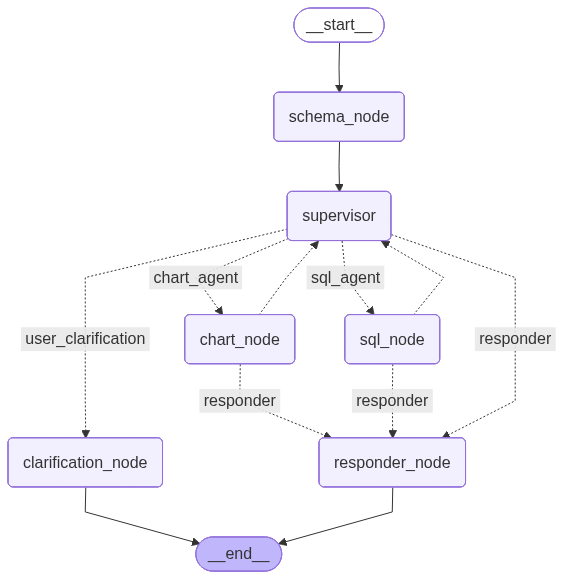

In [31]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [238]:
thread_config = {"configurable": {"thread_id": "test_5"}}

result = app.invoke({
      "messages": [HumanMessage(content="What were the 5 largest electricity prices in Germany in 2024?")],
      "next_node": None,
      "sql_result": None,
      "schema_context": None,
      "queue_responder": False
  }, config=thread_config)

print(result["messages"][-1].content)

What were the 5 largest electricity prices in Germany in 2024?


The user's question requires querying the database for the largest electricity prices in Germany for the year 2024. Therefore, the next task should be to use the sql_agent to retrieve this data. Since the responder will need the results from the SQL query to answer the user's question, I will set queue_responder to True.
sql_agent
The five largest electricity prices in Germany for 2024 are as follows: 

1. €0.5887 (Q2)
2. €0.5887 (Q2)
3. €0.5803 (Q1)
4. €0.5803 (Q1)
5. €0.526 (Q2)

The highest price occurred in the second quarter, indicating a peak in electricity costs during that period.


In [32]:
thread_config = {"configurable": {"thread_id": "test_chart_3"}}

result = app.invoke({
    "messages": [HumanMessage(content="Show me a bar chart of electricity prices in Germany by year")],
    "next_node": None,
    "sql_result": None,
    "chart_base64": None,
    "schema_context": None,
    "queue_responder": False
}, config=thread_config)

Show me a bar chart of electricity prices in Germany by year


The user's request for a bar chart requires data on electricity prices in Germany by year. First, I need to query the database to retrieve this data, so I will use the sql_agent. After the data is retrieved, I will then route to the chart_agent to create the bar chart. Therefore, I will set queue_responder=False because the chart needs to be created after the SQL query.
sql_agent
SQL query completed:This query retrieves the average electricity prices in Germany for each year.

Preview of the result:
[
  {
    "year": 2007,
    "average_price": 0.14657121212121213
  },
  {
    "year": 2008,
    "average_price": 0.15408232323232324
  },
  {
    "year": 2009,
    "average_price": 0.15884292929292929
  },
  {
    "year": 2010,
    "average_price": 0.16407323232323232
  },
  {
    "year": 2011,
    "average_price": 0.1735969696969697
  }
]



The next task is to create a bar chart of the electricity prices in Germany by year, as

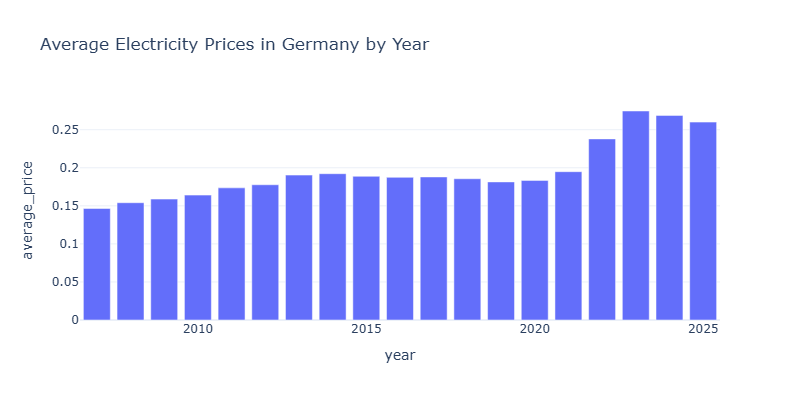

The bar chart of average electricity prices in Germany by year shows a general upward trend from 2007 to 2023, with prices increasing significantly in recent years. In 2023, the average price reached approximately €0.275/kWh, reflecting a notable rise compared to previous years.


In [33]:
from IPython.display import Image, display
import base64

if result["chart_base64"]:
    display(Image(data=base64.b64decode(result["chart_base64"])))
    print(result["messages"][-1].content)
else:
    print("No chart generated")
    print(result["messages"][-1].content)